# Importacion de librerias

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr
from scipy.stats import chi2_contingency

# Exploracion y entendimiento del dataset

Es un dataset sobre los niveles de obesidad en mexico, colombia y peru basado en sus habitos alimenticios y en su condicion fisica

In [47]:
df = pd.read_csv('ObesityDataSet_raw_and_data_sinthetic.csv')
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [48]:
df['FAVC'].value_counts()

FAVC
yes    1866
no      245
Name: count, dtype: int64

In [49]:
df.shape

(2111, 17)

In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

Variable,Tipo,Descripción

Gender-->Categórica,Género de la persona (Female / Male)

Age-->Continua,Edad en años

Height-->Continua,Altura en metros

Weight-->Continua,Peso en kilogramos

family_history_with_overweight-->Binaria,¿Tiene antecedentes familiares de sobrepeso? (yes / no)

FAVC-->Binaria,¿Consume frecuentemente alimentos altos en calorías? (yes / no)

FCVC-->Entero (Ordinal),"Frecuencia de consumo de vegetales en las comidas (1 = Nunca, 2 = A veces, 3 = Siempre)"

NCP-->Continua,Número de comidas principales al día

CAEC-->Categórica,Consumo de comida entre comidas (no / Sometimes / Frequently / Always)

SMOKE-->Binaria,¿Fuma? (yes / no)

CH2O-->Continua,Cantidad de agua consumida diariamente (en litros aproximados)

SCC-->Binaria,¿Monitorea las calorías que consume? (yes / no)

FAF-->Continua,"Frecuencia de actividad física (0 = Ninguna, 3 = Muy frecuente)"

TUE-->Continua,Tiempo de uso de dispositivos tecnológicos al día (en horas)

CALC-->Categórica,Frecuencia de consumo de alcohol (no / Sometimes / Frequently / Always)

MTRANS-->Categórica,"Medio de transporte habitual (Public_Transportation, Automobile, Walking, Motorbike, Bike)"

NObeyesdad-->Categórica (Target),"Nivel de obesidad (Insufficient_Weight, Normal_Weight, Overweight_Level_I, Overweight_Level_II, Obesity_Type_I, Obesity_Type_II, Obesity_Type_III)"

In [51]:
df['CH2O'].value_counts()

CH2O
2.000000    448
1.000000    211
3.000000    162
2.825629      3
1.636326      3
           ... 
1.728139      1
2.005130      1
2.054193      1
2.852339      1
2.863513      1
Name: count, Length: 1268, dtype: int64

# Transformacion de Categoricos a numericos

Para transformar de categoricos a numericos vamos a usar ordinals y one hot.

Gender--> Binaria

family_history_with_overweight-->Binaria

FAVC--> binaria

CAEC-->ordinal

smoke-->binaria

SCC	--> binaria

CALC--> ordinal

MTRANS--> one hot

NObeyesdad--> ordinal


## Ordinal

In [52]:
df['CALC'].value_counts()

CALC
Sometimes     1401
no             639
Frequently      70
Always           1
Name: count, dtype: int64

In [53]:
df['CAEC'].value_counts()

CAEC
Sometimes     1765
Frequently     242
Always          53
no              51
Name: count, dtype: int64

In [54]:
#columnas que vamos a aplicar ordinal
colums = ['CAEC','CALC']

# Se asigna en orden los valores que va a tener al aplicar el metodo ordinal (0,1,2,3)
categories_ordinal=[['no','Sometimes','Frequently','Always'],# orden para CAEC
                    ['no','Sometimes','Frequently','Always']]#ORden para CALC

In [55]:
# asignacion de valores ordinal
encoded_ord = OrdinalEncoder(categories=categories_ordinal) # se crea el objeto para aplicar el fit_transform, con las categorias creadas

df_encoded = encoded_ord.fit_transform(df[colums])# se hace el ordinal

df[colums] = df_encoded # se asignan esos resultados al dataframe original
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,1.0,no,2.0,no,0.0,1.0,0.0,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,1.0,yes,3.0,yes,3.0,0.0,1.0,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,1.0,no,2.0,no,2.0,1.0,2.0,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,1.0,no,2.0,no,2.0,0.0,2.0,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,1.0,no,2.0,no,0.0,0.0,1.0,Public_Transportation,Overweight_Level_II


quedo de la siguiente forma para las dos columnas(['CAEC','CALC'])

no---> 0

Sometimes---> 1

Frequently---> 2

Always---> 3

In [56]:
df['NObeyesdad'].value_counts()

NObeyesdad
Obesity_Type_I         351
Obesity_Type_III       324
Obesity_Type_II        297
Overweight_Level_I     290
Overweight_Level_II    290
Normal_Weight          287
Insufficient_Weight    272
Name: count, dtype: int64

In [57]:
print(df['NObeyesdad'].unique())

<StringArray>
[      'Normal_Weight',  'Overweight_Level_I', 'Overweight_Level_II',
      'Obesity_Type_I', 'Insufficient_Weight',     'Obesity_Type_II',
    'Obesity_Type_III']
Length: 7, dtype: str


In [58]:
# Mapeamos las categorias que se van converitr en numericas
categories_ordinal_NObesyesdad = [['Insufficient_Weight','Normal_Weight','Overweight_Level_I','Overweight_Level_II','Obesity_Type_I','Obesity_Type_II','Obesity_Type_III']] # para que funcione necesita pasarle una lista de listas
column_or=['NObeyesdad']

In [59]:
encoded_ord_obeyesdad = OrdinalEncoder(categories=categories_ordinal_NObesyesdad)
df_encoded_ = encoded_ord_obeyesdad.fit_transform(df[column_or])
df[column_or] =df_encoded_ 
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,1.0,no,2.0,no,0.0,1.0,0.0,Public_Transportation,1.0
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,1.0,yes,3.0,yes,3.0,0.0,1.0,Public_Transportation,1.0
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,1.0,no,2.0,no,2.0,1.0,2.0,Public_Transportation,1.0
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,1.0,no,2.0,no,2.0,0.0,2.0,Walking,2.0
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,1.0,no,2.0,no,0.0,0.0,1.0,Public_Transportation,3.0


Quedo de la siguiente forma

Insufficient_Weight--> 0

Normal_Weight--> 1

Overweight_Level_I--> 2

Overweight_Level_II--> 3

Obesity_Type_I--> 4

Obesity_Type_II--> 5

Obesity_Type_III--> 6

## One Hot

In [60]:
encoder_one = OneHotEncoder(sparse_output=False) # inicializamos el objeto

df_one =encoder_one.fit_transform(df[['MTRANS']])
print(df_one)

[[0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0.]
 ...
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0.]]


In [61]:
print(encoder_one.get_feature_names_out())
columns_one = encoder_one.get_feature_names_out() # Para llamar las columnas en el orden que establecio one hot que es alfabetico

['MTRANS_Automobile' 'MTRANS_Bike' 'MTRANS_Motorbike'
 'MTRANS_Public_Transportation' 'MTRANS_Walking']


In [62]:
# ahora lo convertimos a un dataFrame
df_one = pd.DataFrame(df_one, 
                      columns = columns_one, 
                      index=df.index)

# lo concatenamos al df original
df = pd.concat([df.drop(columns=['MTRANS']),df_one],axis = 1)
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,...,SCC,FAF,TUE,CALC,NObeyesdad,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,1.0,no,...,no,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,1.0,yes,...,yes,3.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,1.0,no,...,no,2.0,1.0,2.0,1.0,0.0,0.0,0.0,1.0,0.0
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,1.0,no,...,no,2.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,1.0
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,1.0,no,...,no,0.0,0.0,1.0,3.0,0.0,0.0,0.0,1.0,0.0


# Estandarizacion de variables

Age-->Continua,Edad en años

Height-->Continua,Altura en metros

Weight-->Continua,Peso en 

NCP-->Continua,Número de comidas principales al día

CH2O-->Continua,Cantidad de agua consumida diariamente (en litros aproximados)

FAF-->Continua,"Frecuencia de actividad física (0 = Ninguna, 3 = Muy frecuente)"

TUE-->Continua,Tiempo de uso de dispositivos tecnológicos al día (en horas)


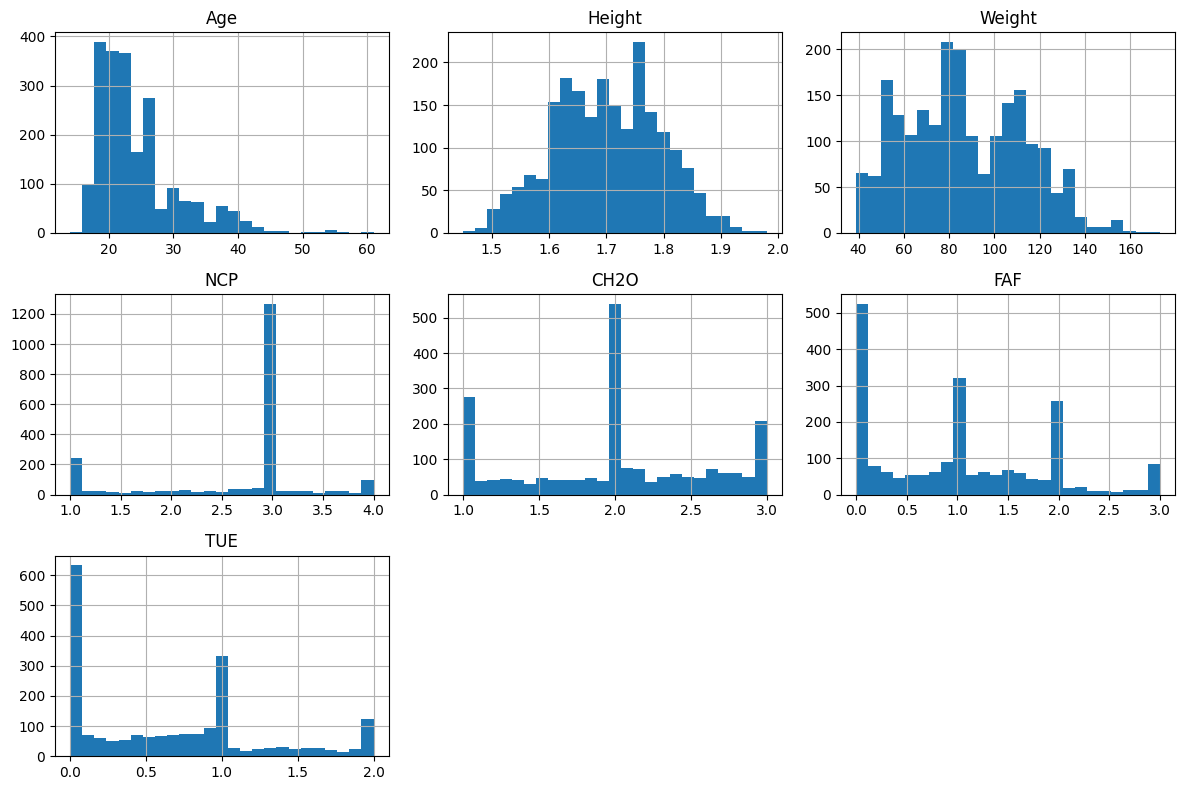

In [63]:
columnas_std = ['Age', 'Height','Weight', 'NCP', 'CH2O', 'FAF', 'TUE']

df[columnas_std].hist(figsize=(12, 8), bins=25)
plt.tight_layout()
plt.show()

In [64]:
scaler = StandardScaler()
df_std = scaler.fit_transform(df[columnas_std])
df[columnas_std] = df_std
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,...,SCC,FAF,TUE,CALC,NObeyesdad,MTRANS_Automobile,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,Female,-0.522124,-0.875589,-0.862558,yes,no,2.0,0.404153,1.0,no,...,no,-1.188039,0.561997,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,Female,-0.522124,-1.947599,-1.168077,yes,no,3.0,0.404153,1.0,yes,...,yes,2.339750,-1.080625,1.0,1.0,0.0,0.0,0.0,1.0,0.0
2,Male,-0.206889,1.054029,-0.366090,yes,no,2.0,0.404153,1.0,no,...,no,1.163820,0.561997,2.0,1.0,0.0,0.0,0.0,1.0,0.0
3,Male,0.423582,1.054029,0.015808,no,no,3.0,0.404153,1.0,no,...,no,1.163820,-1.080625,2.0,2.0,0.0,0.0,0.0,0.0,1.0
4,Male,-0.364507,0.839627,0.122740,no,no,2.0,-2.167023,1.0,no,...,no,-1.188039,-1.080625,1.0,3.0,0.0,0.0,0.0,1.0,0.0


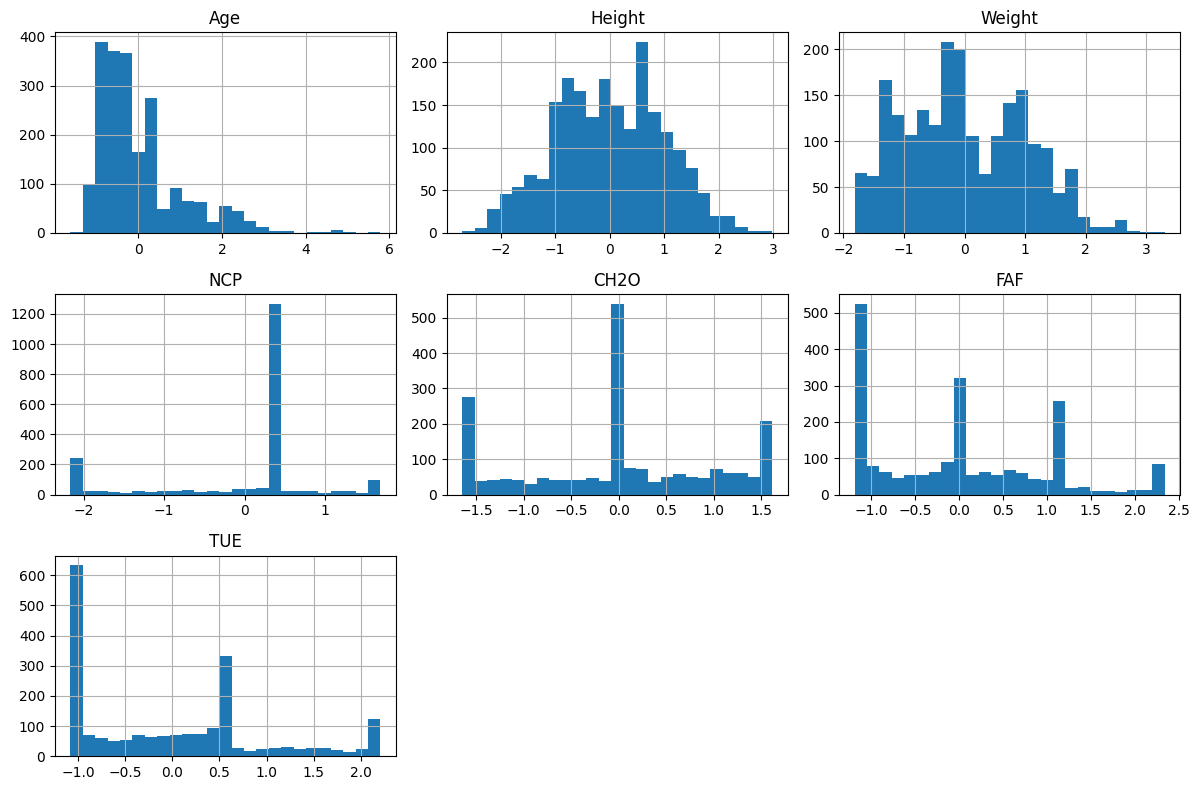

In [65]:
df[columnas_std].hist(figsize=(12, 8), bins=25)
plt.tight_layout()
plt.show()

# Preguntas


## 1. ¿Si la persona tiene historial de sobre peso en su familia es mas probable que presente cualquier tipo de obesidad?|

In [66]:
print(df['NObeyesdad'].value_counts())

NObeyesdad
4.0    351
6.0    324
5.0    297
2.0    290
3.0    290
1.0    287
0.0    272
Name: count, dtype: int64


In [67]:
df['Tiene_Obesidad'] = df['NObeyesdad'] >= 4 # se crea una columna para determinar si tiene cualquier tipo de obesidad
print(df['Tiene_Obesidad'].value_counts())

Tiene_Obesidad
False    1139
True      972
Name: count, dtype: int64


In [68]:
col_historial = 'family_history_with_overweight'
tabla = (df.groupby('family_history_with_overweight')['Tiene_Obesidad'].value_counts(normalize=True).mul(100).rename('Porcentaje')).round(2)
print(tabla)

family_history_with_overweight  Tiene_Obesidad
no                              False             97.92
                                True               2.08
yes                             True              55.85
                                False             44.15
Name: Porcentaje, dtype: float64


In [69]:
resumen = (df.groupby(col_historial)['Tiene_Obesidad']
             .mean()
             .mul(100)
             .round(1))
print("% con algún tipo de obesidad:")
print(resumen.rename({0: 'Sin historial (0)', 1: 'Con historial (1)'}))


% con algún tipo de obesidad:
family_history_with_overweight
no      2.1
yes    55.9
Name: Tiene_Obesidad, dtype: float64


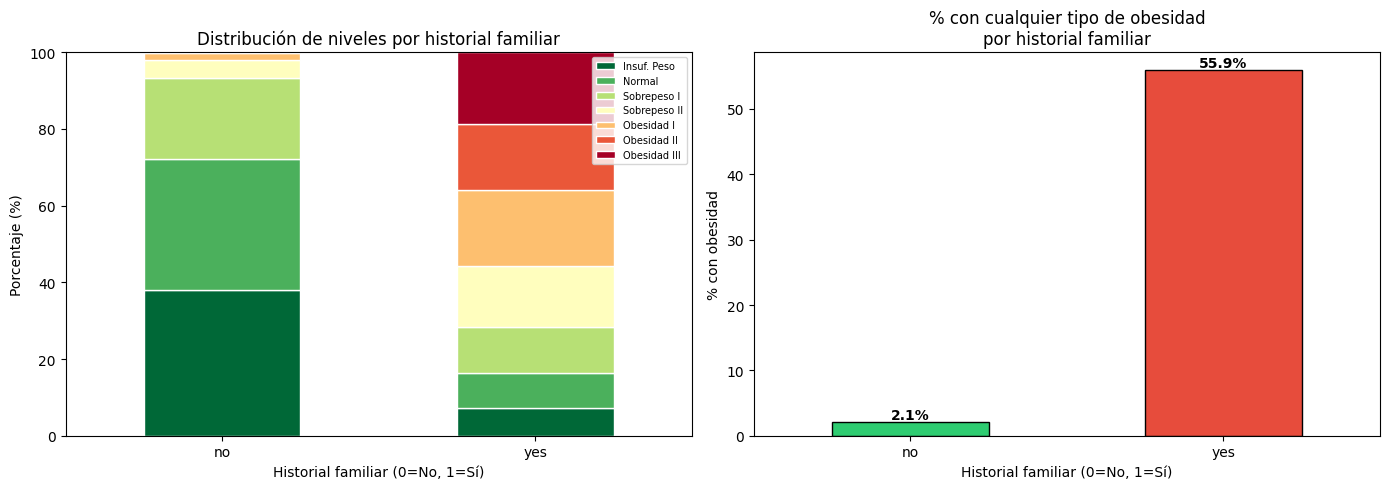

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 4a. Distribución de niveles (0-6) por historial familiar
prop = (df.groupby([col_historial, 'NObeyesdad'])
          .size()
          .unstack(fill_value=0))
prop = prop.div(prop.sum(axis=1), axis=0) * 100

etiquetas_niveles = ['Insuf. Peso', 'Normal', 'Sobrepeso I',
                     'Sobrepeso II', 'Obesidad I', 'Obesidad II', 'Obesidad III']
prop.columns = etiquetas_niveles[:len(prop.columns)]

prop.plot(kind='bar', stacked=True, ax=axes[0], colormap='RdYlGn_r', edgecolor='white')
axes[0].set_title('Distribución de niveles por historial familiar')
axes[0].set_xlabel('Historial familiar (0=No, 1=Sí)')
axes[0].set_ylabel('Porcentaje (%)')
axes[0].legend(loc='upper right', fontsize=7)
axes[0].tick_params(axis='x', rotation=0)
# 4b. % con obesidad por grupo
colores = ['#2ecc71', '#e74c3c']
resumen.plot(kind='bar', ax=axes[1], color=colores, edgecolor='black')
axes[1].set_title('% con cualquier tipo de obesidad\npor historial familiar')
axes[1].set_xlabel('Historial familiar (0=No, 1=Sí)')
axes[1].set_ylabel('% con obesidad')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(resumen):
    axes[1].text(i, v + 0.5, f'{v}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


### Grafica: Distribucion de niveles por historial familiar

Como se ve en la grafica en no(no tienen familiares con historial de obesidad), es mejor el numero de personas sin obesidad pues tienen un mayor porcentaje caso contrario a que si tienen ese historial que es mayor las personas que lo presentan y hasta tienen obesidad en tipo 3 por lo que con esta muestra de datos se aprecia que si hay diferencia entre si sus familiares presentaron obesidad o no

A partir de la gráfica de distribución de niveles de peso según el historial familiar, se puede observar una diferencia notable entre ambos grupos. En el grupo sin historial familiar de sobrepeso (0), predominan las categorías de peso normal e insuficiente, representando la mayor proporción de sus integrantes, lo que indica que la ausencia de antecedentes familiares está asociada a un mejor estado de peso.
Por el contrario, en el grupo con historial familiar (1), la distribución se inclina considerablemente hacia las categorías de obesidad, siendo este grupo el único que presenta casos de Obesidad Tipo III. Esto sugiere que las personas con antecedentes familiares de sobrepeso no solo tienen mayor presencia de obesidad en general, sino que también alcanzan los niveles de mayor gravedad.
Con base en esta muestra, se puede concluir que sí existe una diferencia apreciable entre ambos grupos: tener historial familiar de sobrepeso está asociado con una mayor probabilidad de presentar algún tipo de obesidad, mientras que la ausencia de dicho historial se relaciona con un perfil de peso más saludable.


### Porcentaje con cualquier tipo de obesidad por historial familiar

Como vemos en la grafica las personas que no tienen ese historial en la familia y tienen obesidad es muy bajito (2.1%) y los que si lo presentan hay un mayor % de presentar cualquier tipo de obesidad

La gráfica de porcentajes refuerza la conclusión anterior con cifras concretas. Las personas sin historial familiar de sobrepeso presentan un porcentaje notablemente bajo de obesidad, apenas el 2.1%, lo que indica que este grupo rara vez desarrolla algún tipo de obesidad.
En contraste, las personas que sí tienen antecedentes familiares de sobrepeso muestran un porcentaje considerablemente mayor, lo que evidencia una asociación clara entre el historial familiar y la probabilidad de desarrollar obesidad.
En conclusión, con base en esta muestra, se puede afirmar que tener historial familiar de sobrepeso incrementa de forma significativa la probabilidad de presentar cualquier tipo de obesidad en comparación con quienes no cuentan con dichos antecedentes.

## 2.¿Que genero presenta mayor peso?
 

In [71]:
df_Male= df[df['Gender']== 'Male']
df_Male = df_Male[df_Male['NObeyesdad'] >= 2]
print(df_Male['NObeyesdad'].count())
print(df_Male['NObeyesdad'].value_counts())


823
NObeyesdad
5.0    295
4.0    195
3.0    187
2.0    145
6.0      1
Name: count, dtype: int64


In [72]:
df_Female= df[df['Gender']== 'Female']
df_Female = df_Female[df_Female['NObeyesdad'] >= 2]
print(df_Female['NObeyesdad'].count())
print(df_Female['NObeyesdad'].value_counts())


729
NObeyesdad
6.0    323
4.0    156
2.0    145
3.0    103
5.0      2
Name: count, dtype: int64


Text(0, 0.5, 'Cantidad de personas')

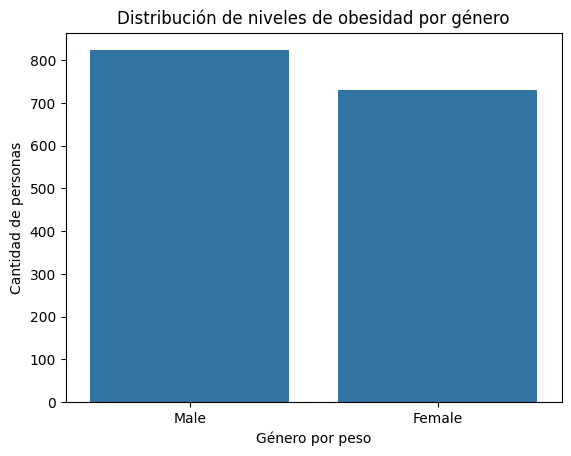

In [73]:
df_VS = df[df['NObeyesdad']>=2] # para analizar que tanto hay por genero
sns.countplot(data=df_VS, x='Gender')
plt.title('Distribución de niveles de obesidad por género')
plt.xlabel('Género por peso')
plt.ylabel('Cantidad de personas')

Text(0.5, 0, 'Nivel de obesidad (0-6)')

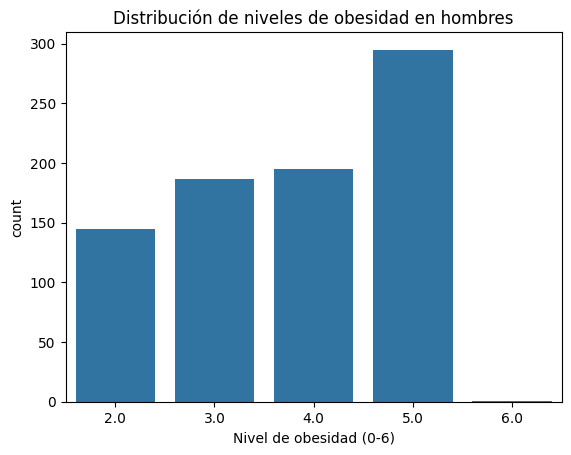

In [74]:
sns.countplot(data=df_Male, x='NObeyesdad')
plt.title('Distribución de niveles de obesidad en hombres')
plt.xlabel('Nivel de obesidad (0-6)')

Text(0.5, 0, 'Nivel de obesidad (0-6)')

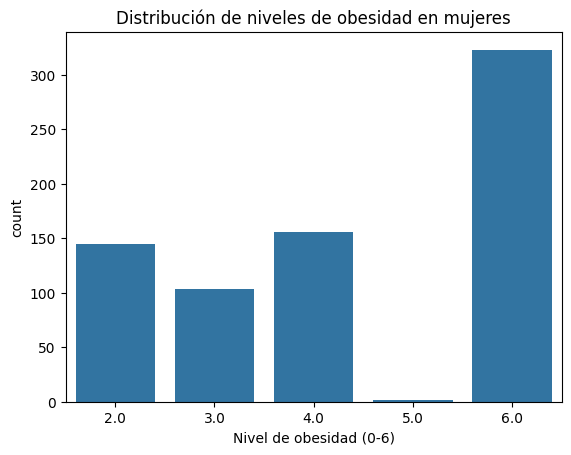

In [75]:
sns.countplot(data=df_Female, x='NObeyesdad')
plt.title('Distribución de niveles de obesidad en mujeres')
plt.xlabel('Nivel de obesidad (0-6)')

La gráfica de Distribución de niveles de obesidad por género muestra que los hombres (~825 personas) superan ligeramente en cantidad a las mujeres (~735) dentro de la muestra con sobrepeso u obesidad, sin embargo la diferencia en cantidad no es suficiente para responder la pregunta, por lo que es necesario observar la distribución de niveles.
Al comparar la Distribución de niveles de obesidad en hombres y la Distribución de niveles de obesidad en mujeres se encuentran diferencias importantes. En los hombres, el nivel predominante es el 5 (Obesidad Tipo II) con casi 300 casos, seguido del nivel 4 y 3, sin presencia notable del nivel 6. En las mujeres, en cambio, el nivel predominante es el 6 (Obesidad Tipo III) con más de 325 casos, siendo el nivel más grave del dataset, mientras que los niveles intermedios son menores.
En conclusión, aunque ambos géneros presentan obesidad, las mujeres tienden a concentrarse en el nivel más severo (Obesidad Tipo III), lo que indica que, en esta muestra, las mujeres presentan un mayor peso en términos de gravedad del nivel de obesidad alcanzado.

# 3. ¿ A mayor consumo de agua menor obesidad?

In [76]:
# Correlación entre consumo de agua y nivel de obesidad
corr, p_value = pearsonr(df['CH2O'], df['NObeyesdad'])

print(f"Correlación de Pearson: {corr:.4f}")
print(f"P-value: {p_value:.4f}")

Correlación de Pearson: 0.1330
P-value: 0.0000


/tmp/ipykernel_22554/2657085771.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='NObeyesdad', y='CH2O', palette='RdYlGn_r', legend=False)


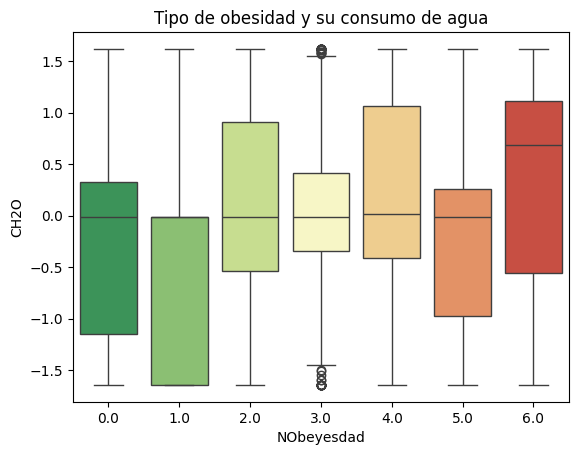

In [80]:
# 4a. Boxplot: distribución de agua por nivel de obesidad
sns.boxplot(data=df, x='NObeyesdad', y='CH2O', palette='RdYlGn_r', legend=False)
plt.title('Tipo de obesidad y su consumo de agua')

plt.show()

A partir del boxplot Tipo de obesidad y su consumo de agua, no se observa una tendencia clara y consistente que confirme que a mayor consumo de agua menor es el nivel de obesidad. Las medianas de CH2O en todos los niveles se mantienen cercanas a 0, lo que indica que el consumo de agua es similar entre los distintos niveles de obesidad.
Esto se refuerza con el valor de correlación de Pearson, que al ser cercano a 0 indica que no existe una relación lineal significativa entre el consumo de agua y el nivel de obesidad en esta muestra. Por lo tanto, no se puede afirmar que a mayor consumo de agua menor obesidad.

# Posibles preguntas

Exploratorias

¿Cuál es la distribución de los niveles de obesidad en el dataset?

¿Qué porcentaje de la muestra corresponde a cada género?

¿Cuál es la edad promedio de las personas con obesidad tipo III?

¿Cuántas personas tienen antecedentes familiares de sobrepeso?


De correlación

¿Existe relación entre la frecuencia de actividad física (FAF) y el nivel de obesidad?

¿Los personas que consumen comida calórica frecuentemente (FAVC) tienen mayor peso?

¿A mayor consumo de agua (CH2O) menor nivel de obesidad?

¿El tiempo de uso de tecnología (TUE) se relaciona con menor actividad física?

¿Existe diferencia en el IMC entre hombres y mujeres?


Predictivas

¿Qué variables son las más determinantes para predecir el nivel de obesidad?

¿El consumo de vegetales (FCVC) reduce la probabilidad de obesidad?

¿Las personas que monitorean sus calorías (SCC) tienen menor nivel de obesidad?


Comparativas

¿Hay diferencias en los hábitos alimenticios entre estados de peso normal y obesidad tipo I?

¿El medio de transporte habitual (MTRANS) influye en el nivel de obesidad?